In [1]:
#mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#buat folder proyek di Drive
import os
os.makedirs('/content/drive/MyDrive/ML_Portfolio/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/ML_Portfolio/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/ML_Portfolio/figures', exist_ok=True)
print("✅ Folder proyek berhasil dibuat di Google Drive!")

✅ Folder proyek berhasil dibuat di Google Drive!


In [4]:
#upload data
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [5]:
#pindah file ke gdrive
import shutil
shutil.move('/content/creditcard.csv', '/content/drive/MyDrive/ML_Portfolio/data/creditcard.csv')
print("✅ File dipindahkan ke Google Drive!")

✅ File dipindahkan ke Google Drive!


In [6]:
# Install library yang belum tersedia di Colab
!pip install shap imbalanced-learn optuna lightgbm -q

# IMPORT SEMUA LIBRARY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time
import joblib
import os

warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline

# Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Explainability
import shap

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

SAVE_DIR = '/content/drive/MyDrive/ML_Portfolio/figures/'
MODELS_DIR = '/content/drive/MyDrive/ML_Portfolio/models/'

print("✅ Semua library berhasil diimport!")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.5 MB/s eta 0:00:00
✅ Semua library berhasil diimport!
NumPy: 2.0.2 | Pandas: 2.2.2


**Load & Inspeksi Data**

In [7]:
#Load data

df = pd.read_csv('/content/drive/MyDrive/ML_Portfolio/data/creditcard.csv')

print("=" * 55)
print(" INFORMASI DASAR DATASET")
print("=" * 55)
print(f"Jumlah baris    : {df.shape[0]:,}")
print(f"Jumlah kolom    : {df.shape[1]}")
print(f"Ukuran memori   : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\n📌 Tipe data:")
print(df.dtypes.value_counts())
print(f"\n📌 Missing values: {df.isnull().sum().sum()} (total)")
print(f"📌 Duplikat     : {df.duplicated().sum()} baris")

 INFORMASI DASAR DATASET
Jumlah baris    : 284,807
Jumlah kolom    : 31
Ukuran memori   : 67.4 MB

📌 Tipe data:
float64    30
int64       1
Name: count, dtype: int64

📌 Missing values: 0 (total)
📌 Duplikat     : 1081 baris


In [8]:
#menampilkan 5 baris pertama
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
#Statistik deskriptif
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
Time,284807.000000,94813.859575,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.000000,0.000000,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.000000,0.000000,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.000000,-0.000000,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.000000,0.000000,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.000000,0.000000,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.000000,0.000000,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.000000,-0.000000,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.000000,0.000000,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.000000,-0.000000,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [13]:
# CEK DISTRIBUSI TARGET (CLASS IMBALANCE)
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("=" * 45)
print(" DISTRIBUSI KELAS TARGET")
print("=" * 45)
print(f"Normal (0) : {class_counts[0]:,} transaksi ({class_pct[0]:.2f}%)")
print(f"Fraud  (1) : {class_counts[1]:,} transaksi ({class_pct[1]:.3f}%)")
print(f"\nRasio imbalance : 1 : {class_counts[0]//class_counts[1]}")
print("\n  Dataset sangat tidak seimbang!")
print("   → Accuracy bukan metrik yang tepat")
print("   → Gunakan ROC-AUC, Precision-Recall, F1")

 DISTRIBUSI KELAS TARGET
Normal (0) : 284,315 transaksi (99.83%)
Fraud  (1) : 492 transaksi (0.173%)

Rasio imbalance : 1 : 577

  Dataset sangat tidak seimbang!
   → Accuracy bukan metrik yang tepat
   → Gunakan ROC-AUC, Precision-Recall, F1


exploratory Data Analysis

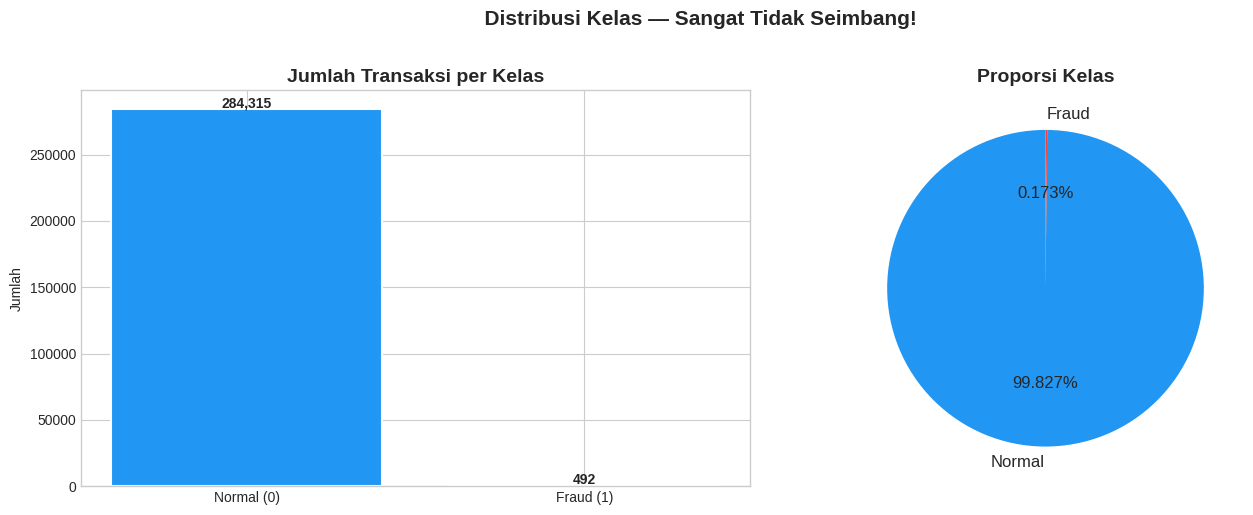

 Tersimpan: 01_class_distribution.png


In [14]:
# PLOT 1: Distribusi Kelas Target
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2196F3', '#F44336']
axes[0].bar(['Normal (0)', 'Fraud (1)'], class_counts.values,
            color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Jumlah Transaksi per Kelas', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Normal', 'Fraud'],
            colors=colors, autopct='%1.3f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Proporsi Kelas', fontsize=14, fontweight='bold')

plt.suptitle('  Distribusi Kelas — Sangat Tidak Seimbang!',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Tersimpan: 01_class_distribution.png")

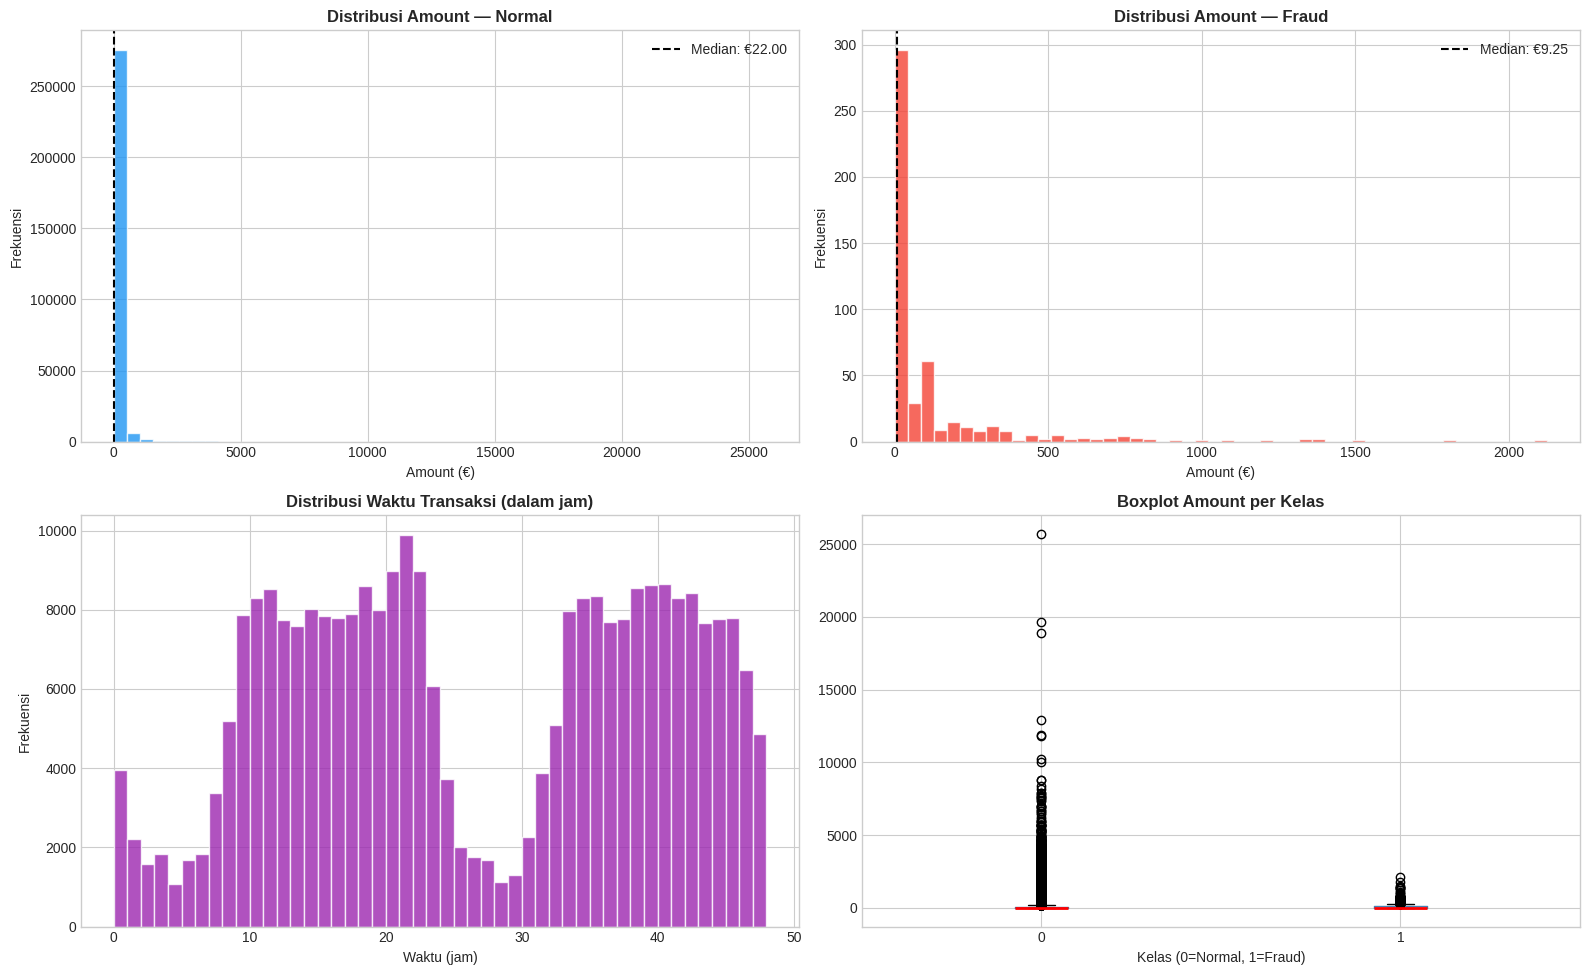

 Tersimpan: 02_amount_time_distribution.png


In [15]:
# PLOT 2: Distribusi Amount & Time
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Amount - normal vs fraud
for i, label in enumerate([0, 1]):
    subset = df[df['Class'] == label]['Amount']
    name = 'Normal' if label == 0 else 'Fraud'
    color = colors[label]
    axes[0][label].hist(subset, bins=50, color=color, alpha=0.8, edgecolor='white')
    axes[0][label].set_title(f'Distribusi Amount — {name}', fontweight='bold')
    axes[0][label].set_xlabel('Amount (€)')
    axes[0][label].set_ylabel('Frekuensi')
    axes[0][label].axvline(subset.median(), color='black', linestyle='--',
                           label=f'Median: €{subset.median():.2f}')
    axes[0][label].legend()

# Time
axes[1][0].hist(df['Time'] / 3600, bins=48, color='#9C27B0', alpha=0.8, edgecolor='white')
axes[1][0].set_title('Distribusi Waktu Transaksi (dalam jam)', fontweight='bold')
axes[1][0].set_xlabel('Waktu (jam)')
axes[1][0].set_ylabel('Frekuensi')

# Amount boxplot per kelas
df.boxplot(column='Amount', by='Class', ax=axes[1][1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1][1].set_title('Boxplot Amount per Kelas', fontweight='bold')
axes[1][1].set_xlabel('Kelas (0=Normal, 1=Fraud)')
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}02_amount_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Tersimpan: 02_amount_time_distribution.png")

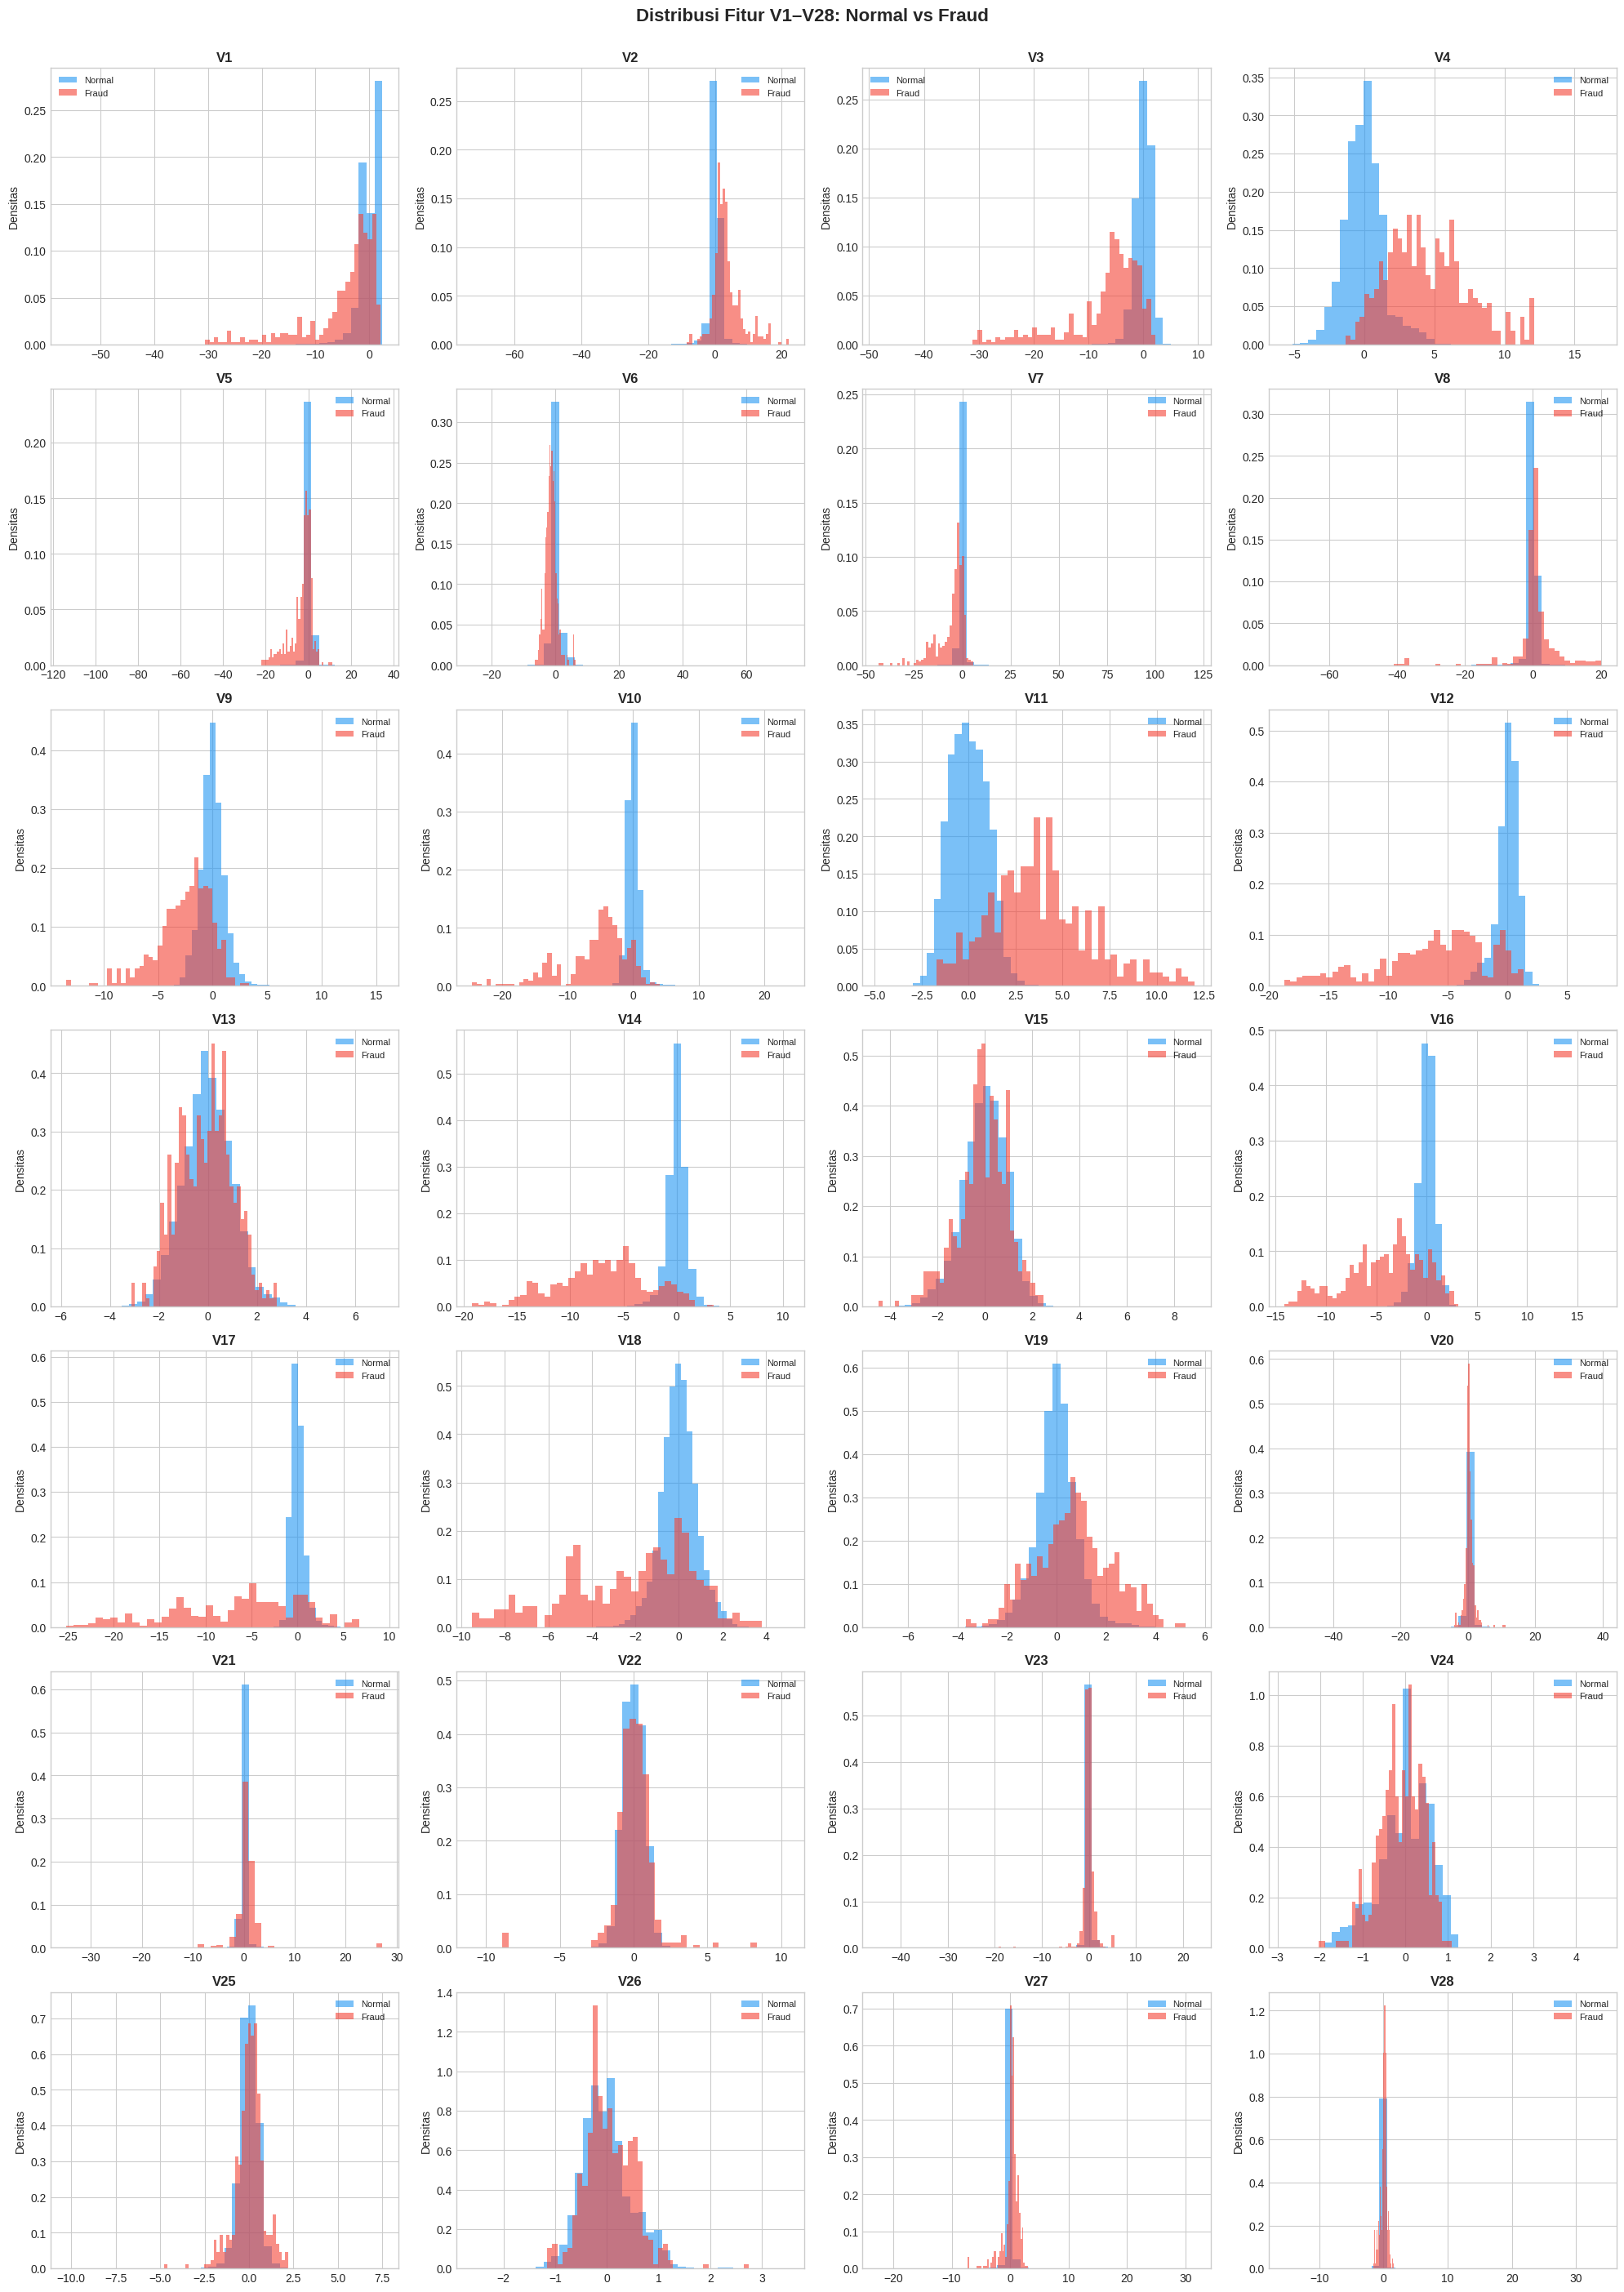

 Tersimpan: 03_feature_distributions.png


In [16]:
# PLOT 3: Fitur V1–V28 — Perbandingan Normal vs Fraud
# ============================================================
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    normal_vals = df[df['Class'] == 0][feat]
    fraud_vals = df[df['Class'] == 1][feat]

    axes[i].hist(normal_vals, bins=40, alpha=0.6, color='#2196F3',
                 label='Normal', density=True)
    axes[i].hist(fraud_vals, bins=40, alpha=0.6, color='#F44336',
                 label='Fraud', density=True)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Densitas')

plt.suptitle('Distribusi Fitur V1–V28: Normal vs Fraud',
             fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Tersimpan: 03_feature_distributions.png")

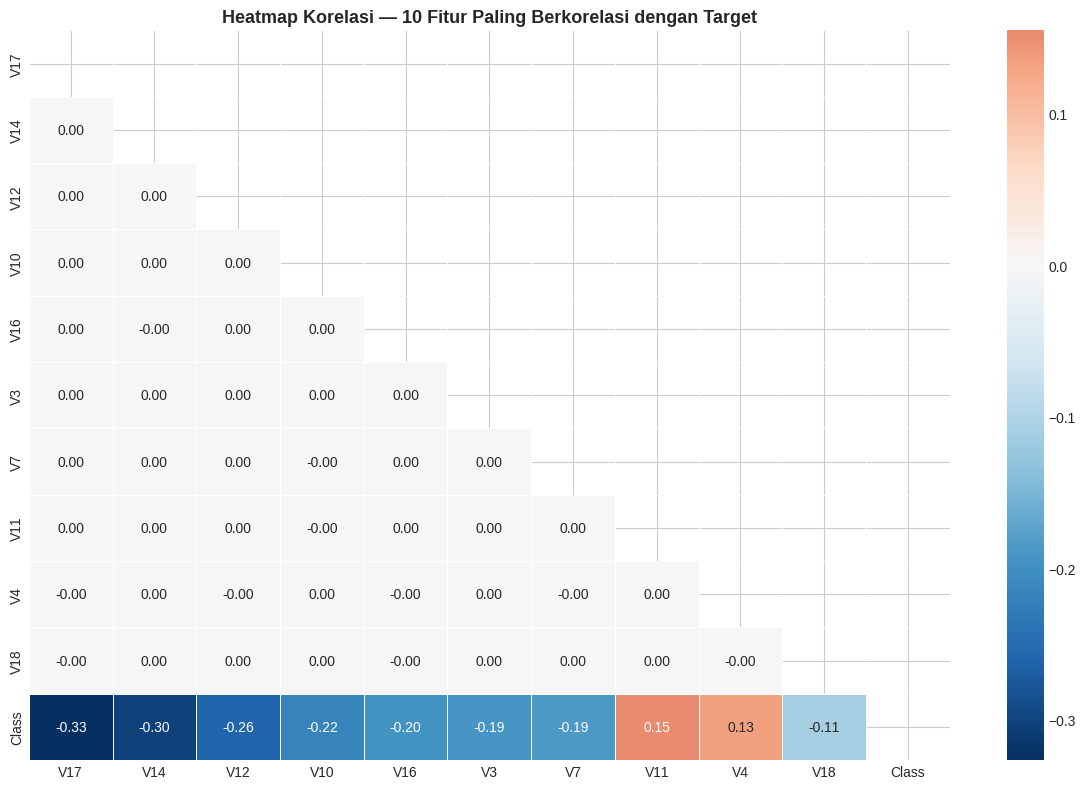


 Top 10 Fitur paling berkorelasi dengan Class (Fraud):
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
 Tersimpan: 04_correlation_heatmap.png


In [18]:
# PLOT 4: Heatmap Korelasi (top fitur)
# ============================================================
corr = df.corr()
target_corr = corr['Class'].drop('Class').abs().sort_values(ascending=False)
top10_features = target_corr.head(10).index.tolist()

plt.figure(figsize=(12, 8))
sns.heatmap(df[top10_features + ['Class']].corr(),
            annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5,
            mask=np.triu(np.ones((11, 11), dtype=bool)))
plt.title('Heatmap Korelasi — 10 Fitur Paling Berkorelasi dengan Target',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Top 10 Fitur paling berkorelasi dengan Class (Fraud):")
print(target_corr.head(10).to_string())
print(" Tersimpan: 04_correlation_heatmap.png")

In [24]:
# RINGKASAN EDA
# ============================================================
print("""
╔══════════════════════════════════════════════════════════╗
║               RINGKASAN TEMUAN EDA                       ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. CLASS IMBALANCE EKSTREM                              ║
║     • Hanya 0.17% transaksi adalah fraud                 ║
║     • Accuracy tidak bisa diandalkan sebagai metrik      ║
║     • Solusi: SMOTE + evaluasi dgn ROC-AUC & Recall      ║
║                                                          ║
║  2. DISTRIBUSI AMOUNT                                    ║
║     • Median fraud (€9.25) << median normal (€22)        ║
║     • Fraud cenderung pada nominal kecil-menengah        ║
║     • Perlu log-transform karena distribusi sangat skewed║
║                                                          ║
║  3. FITUR PCA (V1–V28)                                   ║
║     • V4, V11 → korelasi POSITIF kuat dengan fraud       ║
║     • V17, V14, V12 → korelasi NEGATIF kuat              ║
║     • Distribusinya sangat berbeda antara Normal & Fraud ║
║                                                          ║
║  4. FITUR TIME                                           ║
║     • Pola 2 puncak → sesuai siklus siang/malam          ║
║     • Fraud tersebar relatif merata sepanjang waktu      ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║               RINGKASAN TEMUAN EDA                       ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. CLASS IMBALANCE EKSTREM                              ║
║     • Hanya 0.17% transaksi adalah fraud                 ║
║     • Accuracy tidak bisa diandalkan sebagai metrik      ║
║     • Solusi: SMOTE + evaluasi dgn ROC-AUC & Recall      ║
║                                                          ║
║  2. DISTRIBUSI AMOUNT                                    ║
║     • Median fraud (€9.25) << median normal (€22)        ║
║     • Fraud cenderung pada nominal kecil-menengah        ║
║     • Perlu log-transform karena distribusi sangat skewed║
║                                                          ║
║  3. FITUR PCA (V1–V28)                                   ║
║     • V4, V11 → korelasi POSITIF kuat dengan fraud       ║
║     • V17, V14, V12 →

**Preprocessing**

In [25]:
# FEATURE ENGINEERING
# ============================================================

# Salin dataframe agar data asli tidak berubah
df_proc = df.copy()

# Log-transform Amount (distribusi sangat skewed)
df_proc['log_Amount'] = np.log1p(df_proc['Amount'])

# Normalisasi Time ke dalam jam (0–48 jam)
df_proc['Time_hour'] = (df_proc['Time'] % 86400) / 3600

# Hapus kolom asli yang sudah ditransformasi
df_proc.drop(['Amount', 'Time'], axis=1, inplace=True)

print("✅ Feature Engineering selesai!")
print(f"Fitur baru: log_Amount, Time_hour")
print(f"Shape: {df_proc.shape}")

✅ Feature Engineering selesai!
Fitur baru: log_Amount, Time_hour
Shape: (284807, 31)


In [26]:
# SPLIT DATA — Train / Validation / Test
# ============================================================
X = df_proc.drop('Class', axis=1)
y = df_proc['Class']

# Split 70% train, 15% val, 15% test — stratified (jaga rasio kelas)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("✅ Pembagian data selesai!")
print(f"Train : {X_train.shape[0]:,} baris | Fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Val   : {X_val.shape[0]:,} baris | Fraud: {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
print(f"Test  : {X_test.shape[0]:,} baris | Fraud: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

✅ Pembagian data selesai!
Train : 199,364 baris | Fraud: 344 (0.17%)
Val   : 42,721 baris | Fraud: 74 (0.17%)
Test  : 42,722 baris | Fraud: 74 (0.17%)


In [30]:
# SCALING — RobustScaler (tahan terhadap outlier)
# ============================================================
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform di train
X_val_scaled   = scaler.transform(X_val)          # transform saja di val
X_test_scaled  = scaler.transform(X_test)         # transform saja di test

# Simpan scaler untuk deployment
joblib.dump(scaler, f'{MODELS_DIR}scaler.pkl')
print("✅ Scaling selesai! Scaler tersimpan.")

✅ Scaling selesai! Scaler tersimpan.


In [31]:
# HANDLE CLASS IMBALANCE dengan SMOTE
# ============================================================
smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.1)
# sampling_strategy=0.1 → buat fraud jadi 10% dari total

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("✅ SMOTE selesai!")
print(f"Sebelum SMOTE : {y_train.value_counts().to_dict()}")
print(f"Sesudah SMOTE : {pd.Series(y_train_resampled).value_counts().to_dict()}")
print(f"\nShape setelah SMOTE: {X_train_resampled.shape}")

✅ SMOTE selesai!
Sebelum SMOTE : {0: 199020, 1: 344}
Sesudah SMOTE : {0: 199020, 1: 19902}

Shape setelah SMOTE: (218922, 30)


**Training & Perbandingan Model**

In [32]:
# FUNGSI HELPER — Evaluasi Model
# ============================================================
def evaluate_model(model, X_val, y_val, model_name):
    """Evaluasi model dan kembalikan dictionary hasil."""
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    return {
        'Model': model_name,
        'ROC-AUC': round(roc_auc_score(y_val, y_prob), 4),
        'Avg Precision': round(average_precision_score(y_val, y_prob), 4),
        'F1 Score': round(f1_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred), 4),
        'Recall': round(recall_score(y_val, y_pred), 4),
    }

In [35]:
# LATIH 4 MODEL & BANDINGKAN
# ============================================================
models_dict = {
    'Logistic Regression': LogisticRegression(
        C=0.01, max_iter=500, random_state=42, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=1, random_state=42,
        eval_metric='logloss', verbosity=0, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, verbose=-1, n_jobs=-1
    )
}

results = []
trained_models = {}

print("  Melatih model...\n")
for name, model in models_dict.items():
    start = time.time()
    model.fit(X_train_resampled, y_train_resampled)
    elapsed = time.time() - start

    metrics = evaluate_model(model, X_val_scaled, y_val, name)
    metrics['Train Time (s)'] = round(elapsed, 1)
    results.append(metrics)
    trained_models[name] = model

    print(f" {name:<22} | AUC={metrics['ROC-AUC']:.4f} | "
          f"Recall={metrics['Recall']:.4f} | F1={metrics['F1 Score']:.4f} | "
          f"⏱ {elapsed:.1f}s")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\n PERBANDINGAN MODEL (diurutkan berdasarkan ROC-AUC):")
print(results_df.to_string(index=False))

  Melatih model...

 Logistic Regression    | AUC=0.9713 | Recall=0.8243 | F1=0.4980 | ⏱ 5.9s
 Random Forest          | AUC=0.9781 | Recall=0.7838 | F1=0.7532 | ⏱ 125.2s
 XGBoost                | AUC=0.9756 | Recall=0.7973 | F1=0.8194 | ⏱ 9.0s
 LightGBM               | AUC=0.9806 | Recall=0.8108 | F1=0.8333 | ⏱ 6.4s

 PERBANDINGAN MODEL (diurutkan berdasarkan ROC-AUC):
              Model  ROC-AUC  Avg Precision  F1 Score  Precision  Recall  Train Time (s)
           LightGBM   0.9806         0.8379    0.8333     0.8571  0.8108             6.4
      Random Forest   0.9781         0.8066    0.7532     0.7250  0.7838           125.2
            XGBoost   0.9756         0.8223    0.8194     0.8429  0.7973             9.0
Logistic Regression   0.9713         0.6627    0.4980     0.3567  0.8243             5.9


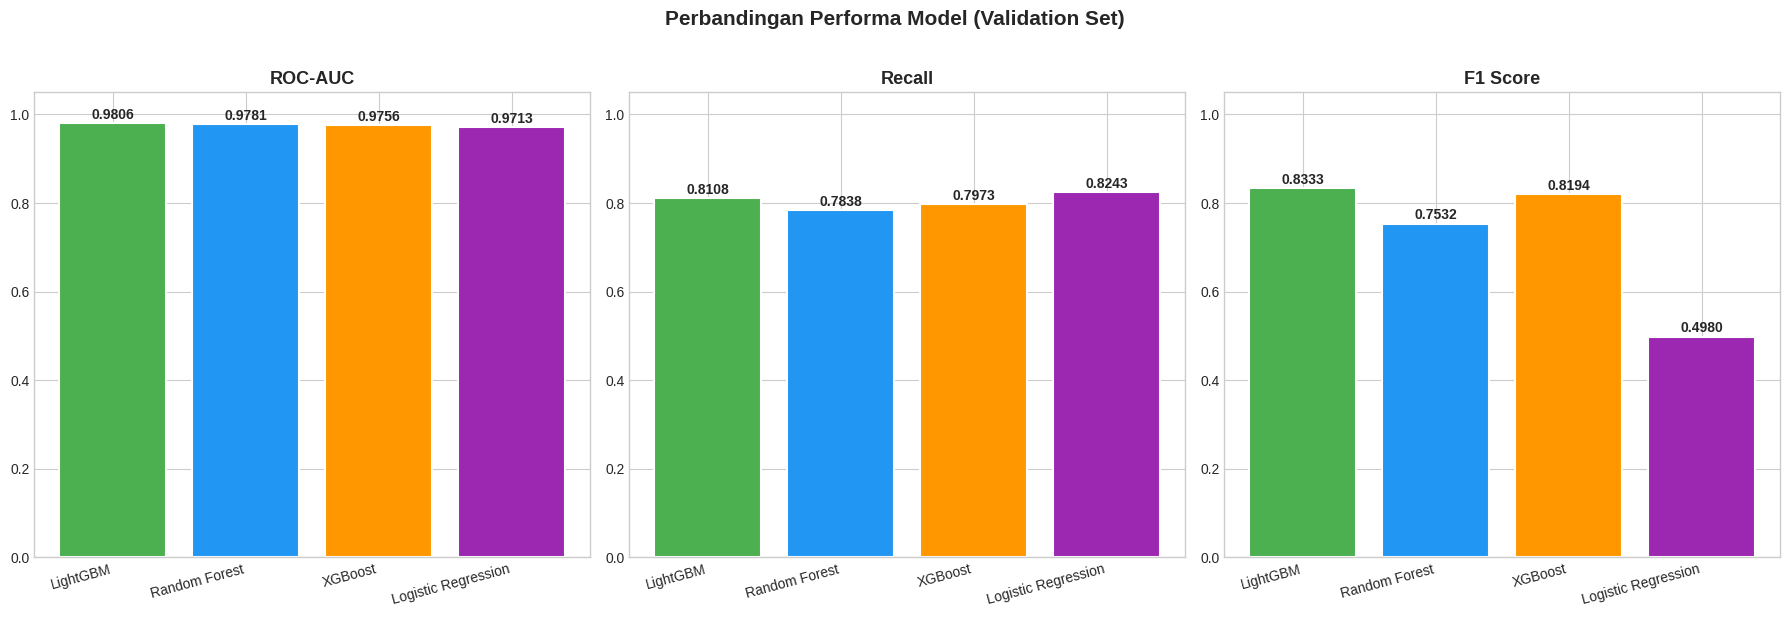

 Tersimpan: 05_model_comparison.png


In [36]:
# VISUALISASI PERBANDINGAN MODEL
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_to_plot = ['ROC-AUC', 'Recall', 'F1 Score']
colors_bar = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']

for idx, metric in enumerate(metrics_to_plot):
    vals = results_df[metric].values
    bars = axes[idx].bar(results_df['Model'], vals,
                          color=colors_bar, edgecolor='white', linewidth=1.5)
    axes[idx].set_title(f'{metric}', fontsize=13, fontweight='bold')
    axes[idx].set_ylim(0, 1.05)
    axes[idx].set_xticklabels(results_df['Model'], rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.01,
                        f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Perbandingan Performa Model (Validation Set)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Tersimpan: 05_model_comparison.png")

In [37]:
import os
print(os.listdir('/content/drive/MyDrive/ML_Portfolio/data/'))
print(os.listdir('/content/drive/MyDrive/ML_Portfolio/models/'))
print(os.listdir('/content/drive/MyDrive/ML_Portfolio/figures/'))

['creditcard.csv']
['model_comparison.csv', 'xgboost_fraud_detector.pkl', 'final_metrics_testset.csv', 'scaler.pkl', 'xgboost_tuned.pkl']
['01_class_distribution.png', '02_amount_time_distribution.png', '03_feature_distributions.png', '04_correlation_heatmap.png', '05_model_comparison.png', '06_confusion_matrix.png', '07_roc_pr_curves.png', '08_threshold_optimization.png', '09_shap_importance.png', '10_shap_beeswarm.png', '11_shap_waterfall_fraud.png']


**Hyperparameter Tuning dengan Optuna**

In [38]:
# TUNING XGBOOST DENGAN OPTUNA
# ============================================================
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 400),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-5, 5.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-5, 5.0, log=True),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0, 1.0),
        'random_state'     : 42,
        'eval_metric'      : 'logloss',
        'verbosity'        : 0,
        'n_jobs'           : -1
    }
    model = XGBClassifier(**params)
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(
        model, X_train_resampled, y_train_resampled,
        cv=kf, scoring='roc_auc', n_jobs=-1
    ).mean()
    return score

print(" Memulai Optuna hyperparameter search (30 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n Optuna selesai!")
print(f"Best ROC-AUC CV : {study.best_value:.5f}")
print(f"Best Params     : {study.best_params}")

 Memulai Optuna hyperparameter search (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


 Optuna selesai!
Best ROC-AUC CV : 0.99999
Best Params     : {'n_estimators': 381, 'max_depth': 6, 'learning_rate': 0.15428832150198216, 'subsample': 0.8235409085707089, 'colsample_bytree': 0.8553815823874531, 'reg_alpha': 0.5679225813226901, 'reg_lambda': 1.0752267690055501, 'min_child_weight': 5, 'gamma': 0.22473887525716227}


In [39]:
# LATIH ULANG DENGAN PARAMETER TERBAIK
# ============================================================
best_params = study.best_params
best_params.update({'random_state': 42, 'eval_metric': 'logloss',
                    'verbosity': 0, 'n_jobs': -1})

best_model = XGBClassifier(**best_params)
best_model.fit(X_train_resampled, y_train_resampled)

# Bandingkan sebelum & sesudah tuning di validation set
baseline = trained_models['XGBoost']
baseline_metrics = evaluate_model(baseline, X_val_scaled, y_val, 'XGBoost Baseline')
tuned_metrics = evaluate_model(best_model, X_val_scaled, y_val, 'XGBoost Tuned')

print("\n PERBANDINGAN SEBELUM & SESUDAH TUNING:")
print(f"{'Metrik':<20} {'Baseline':>12} {'Tuned':>12} {'Delta':>10}")
print("-" * 56)
for key in ['ROC-AUC', 'Avg Precision', 'F1 Score', 'Precision', 'Recall']:
    delta = tuned_metrics[key] - baseline_metrics[key]
    arrow = '↑' if delta > 0 else '↓'
    print(f"{key:<20} {baseline_metrics[key]:>12.4f} {tuned_metrics[key]:>12.4f} "
          f"  {arrow}{abs(delta):.4f}")

# Simpan model
joblib.dump(best_model, f'{MODELS_DIR}xgboost_tuned.pkl')
print("\n Model tuned tersimpan!")


 PERBANDINGAN SEBELUM & SESUDAH TUNING:
Metrik                   Baseline        Tuned      Delta
--------------------------------------------------------
ROC-AUC                    0.9756       0.9807   ↑0.0051
Avg Precision              0.8223       0.8316   ↑0.0093
F1 Score                   0.8194       0.8252   ↑0.0058
Precision                  0.8429       0.8551   ↑0.0122
Recall                     0.7973       0.7973   ↓0.0000

 Model tuned tersimpan!


**Evaluasi Lengkap di Test Set**

In [40]:
# EVALUASI FINAL DI TEST SET (data yang belum pernah dilihat!)
# ============================================================
print(" Mengevaluasi model di TEST SET...\n")

y_pred_test = best_model.predict(X_test_scaled)
y_prob_test = best_model.predict_proba(X_test_scaled)[:, 1]

final_metrics = {
    'ROC-AUC'          : roc_auc_score(y_test, y_prob_test),
    'Avg Precision'    : average_precision_score(y_test, y_prob_test),
    'F1 Score'         : f1_score(y_test, y_pred_test),
    'Precision'        : precision_score(y_test, y_pred_test),
    'Recall'           : recall_score(y_test, y_pred_test),
}

print("╔══════════════════════════════════════════╗")
print("║        HASIL AKHIR — TEST SET            ║")
print("╠══════════════════════════════════════════╣")
for k, v in final_metrics.items():
    bar = '█' * int(v * 20)
    print(f"║  {k:<18} : {v:.4f}  {bar}")
print("╚══════════════════════════════════════════╝")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_test,
                             target_names=['Normal', 'Fraud']))

 Mengevaluasi model di TEST SET...

╔══════════════════════════════════════════╗
║        HASIL AKHIR — TEST SET            ║
╠══════════════════════════════════════════╣
║  ROC-AUC            : 0.9701  ███████████████████
║  Avg Precision      : 0.8382  ████████████████
║  F1 Score           : 0.8356  ████████████████
║  Precision          : 0.8472  ████████████████
║  Recall             : 0.8243  ████████████████
╚══════════════════════════════════════════╝

 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42648
       Fraud       0.85      0.82      0.84        74

    accuracy                           1.00     42722
   macro avg       0.92      0.91      0.92     42722
weighted avg       1.00      1.00      1.00     42722



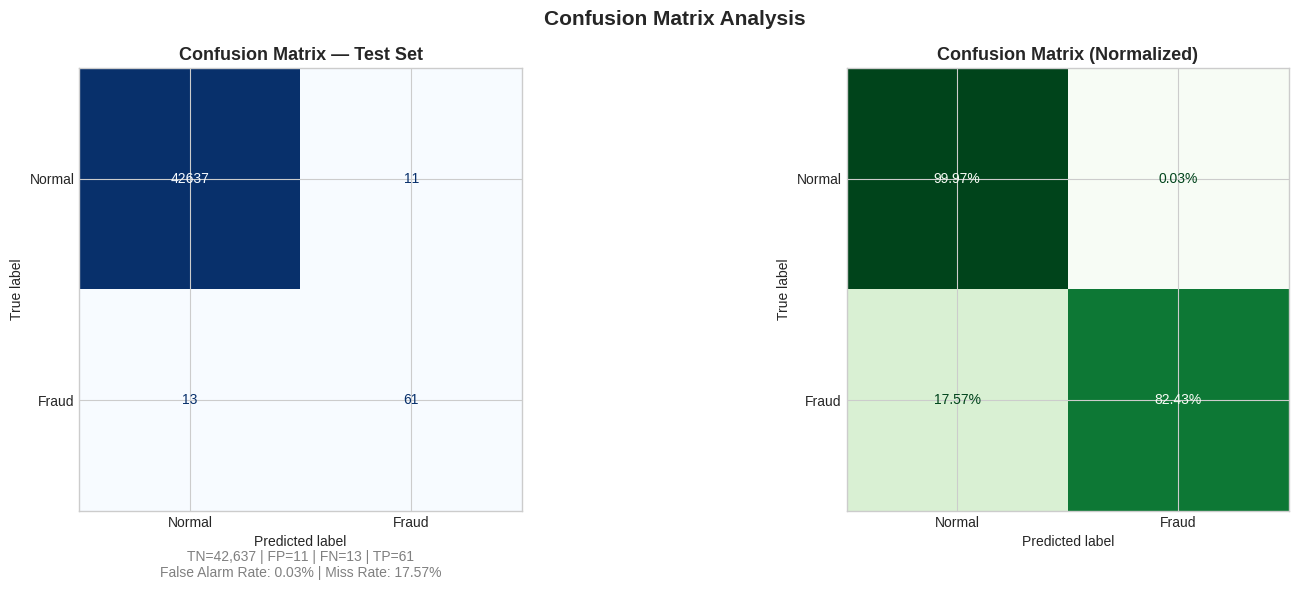

 Tersimpan: 06_confusion_matrix.png


In [41]:
# PLOT 1: Confusion Matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Fraud'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')

# Anotasi tambahan
axes[0].text(0.5, -0.15,
    f"TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}\n"
    f"False Alarm Rate: {fp/(fp+tn)*100:.2f}% | Miss Rate: {fn/(fn+tp)*100:.2f}%",
    ha='center', transform=axes[0].transAxes, fontsize=10, color='gray')

# Normalized confusion matrix
cm_norm = confusion_matrix(y_test, y_pred_test, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Normal', 'Fraud'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False, values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Tersimpan: 06_confusion_matrix.png")

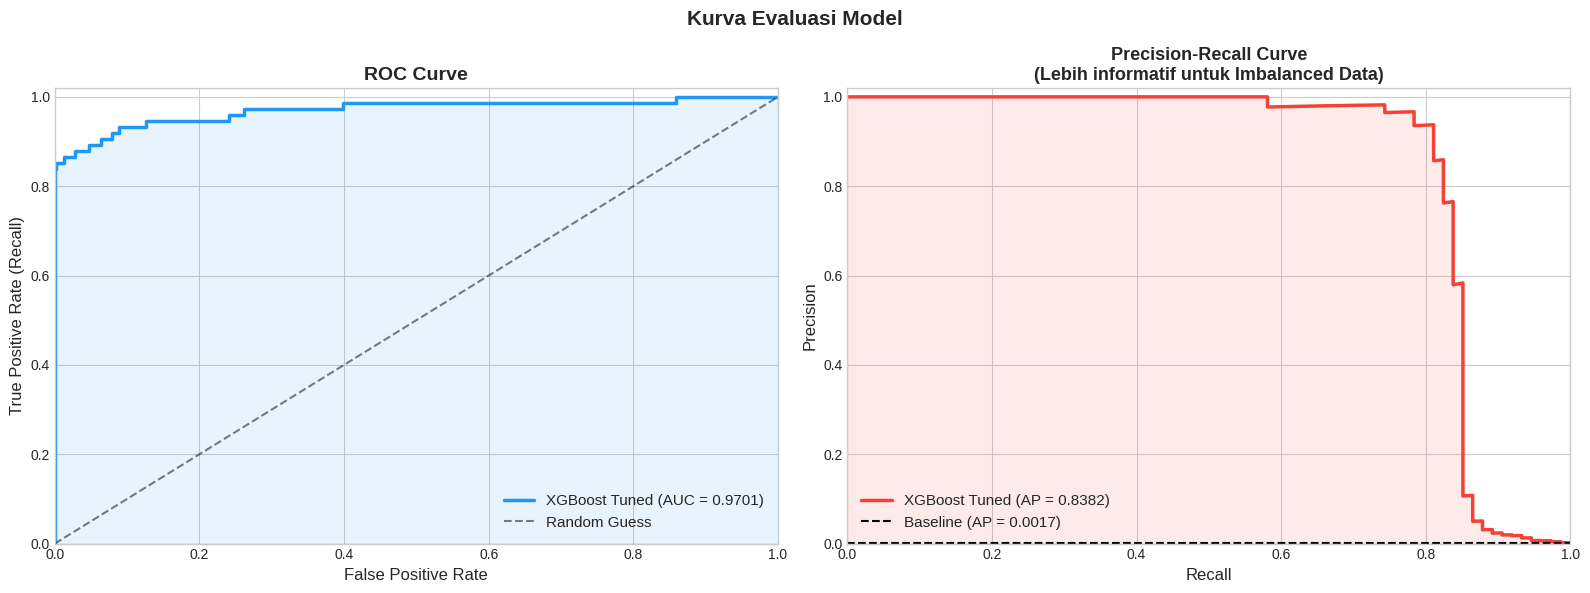

Tersimpan: 07_roc_pr_curves.png


In [42]:
# ============================================================
# PLOT 2: ROC Curve + Precision-Recall Curve
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_test)
roc_auc_val = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#2196F3', lw=2.5,
             label=f'XGBoost Tuned (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Guess')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# Precision-Recall Curve (lebih informatif untuk imbalanced data)
precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_prob_test)
avg_prec = average_precision_score(y_test, y_prob_test)
baseline_pr = y_test.mean()

axes[1].plot(recall_arr, precision_arr, color='#F44336', lw=2.5,
             label=f'XGBoost Tuned (AP = {avg_prec:.4f})')
axes[1].axhline(y=baseline_pr, color='k', linestyle='--', lw=1.5,
                label=f'Baseline (AP = {baseline_pr:.4f})')
axes[1].fill_between(recall_arr, precision_arr, alpha=0.1, color='#F44336')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve\n(Lebih informatif untuk Imbalanced Data)',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Kurva Evaluasi Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}07_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: 07_roc_pr_curves.png")

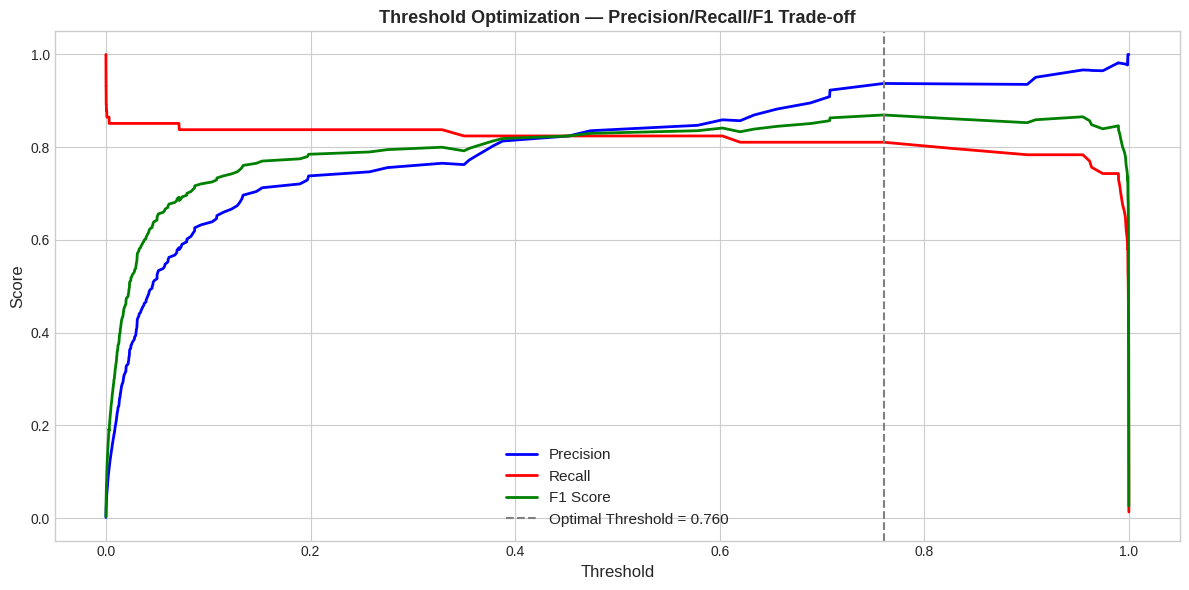

 Optimal Threshold: 0.7602
   → F1 Score pada threshold ini: 0.8696
 Tersimpan: 08_threshold_optimization.png


In [43]:
# PLOT 3: Threshold Optimization
# (Tentukan threshold optimal untuk Precision-Recall trade-off)
# ============================================================
precision_arr2, recall_arr2, thresholds_pr = precision_recall_curve(y_test, y_prob_test)
f1_arr = 2 * (precision_arr2[:-1] * recall_arr2[:-1]) / \
         (precision_arr2[:-1] + recall_arr2[:-1] + 1e-10)

optimal_idx = np.argmax(f1_arr)
optimal_threshold = thresholds_pr[optimal_idx]

plt.figure(figsize=(12, 6))
plt.plot(thresholds_pr, precision_arr2[:-1], 'b-', lw=2, label='Precision')
plt.plot(thresholds_pr, recall_arr2[:-1], 'r-', lw=2, label='Recall')
plt.plot(thresholds_pr, f1_arr, 'g-', lw=2, label='F1 Score')
plt.axvline(optimal_threshold, color='gray', linestyle='--', lw=1.5,
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Threshold Optimization — Precision/Recall/F1 Trade-off',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}08_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Optimal Threshold: {optimal_threshold:.4f}")
print(f"   → F1 Score pada threshold ini: {f1_arr[optimal_idx]:.4f}")
print(" Tersimpan: 08_threshold_optimization.png")

**SHAP Explainability**

In [44]:
# SHAP — Memahami Keputusan Model
# ============================================================
print(" Menghitung SHAP values... ")

# menggunakan sample untuk efisiensi (1000 data test)
sample_idx = np.random.choice(len(X_test_scaled), 1000, replace=False)
X_test_sample = X_test.iloc[sample_idx]
X_test_scaled_sample = X_test_scaled[sample_idx]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled_sample)

print("✅ SHAP values berhasil dihitung!")

 Menghitung SHAP values... 
✅ SHAP values berhasil dihitung!


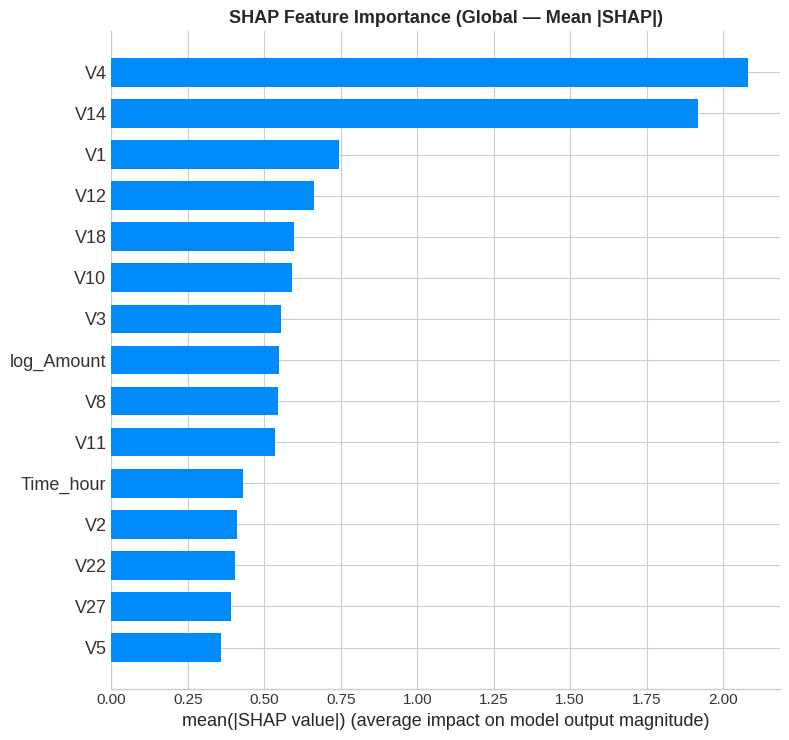

 Tersimpan: 09_shap_importance.png


In [45]:
# PLOT SHAP 1: Feature Importance Global
# ============================================================
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sample,
                  feature_names=X_test.columns.tolist(),
                  plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance (Global — Mean |SHAP|)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}09_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Tersimpan: 09_shap_importance.png")

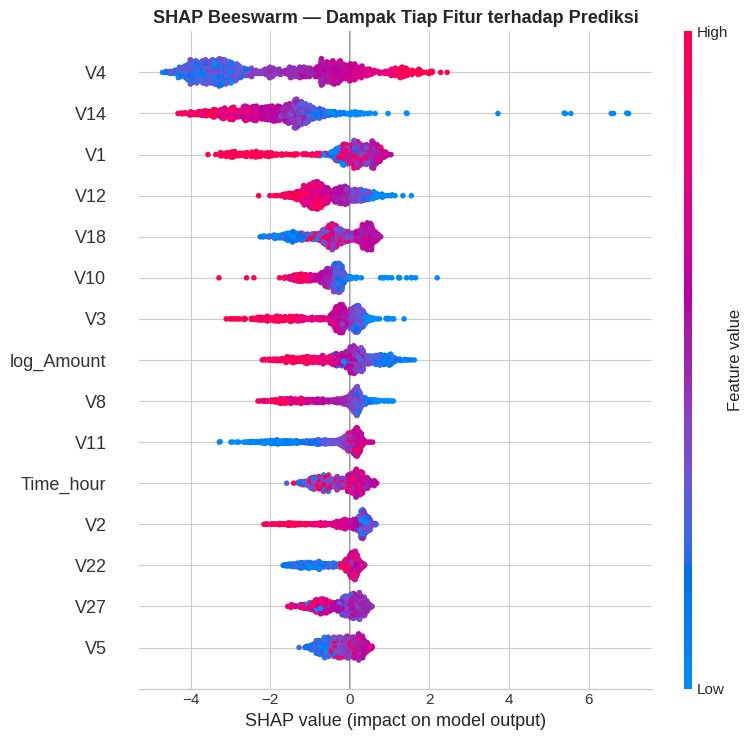

 Tersimpan: 10_shap_beeswarm.png


In [46]:
# PLOT SHAP 2: Beeswarm — Distribusi Dampak per Fitur
# ============================================================
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample,
                  feature_names=X_test.columns.tolist(),
                  max_display=15, show=False)
plt.title('SHAP Beeswarm — Dampak Tiap Fitur terhadap Prediksi',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}10_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Tersimpan: 10_shap_beeswarm.png")

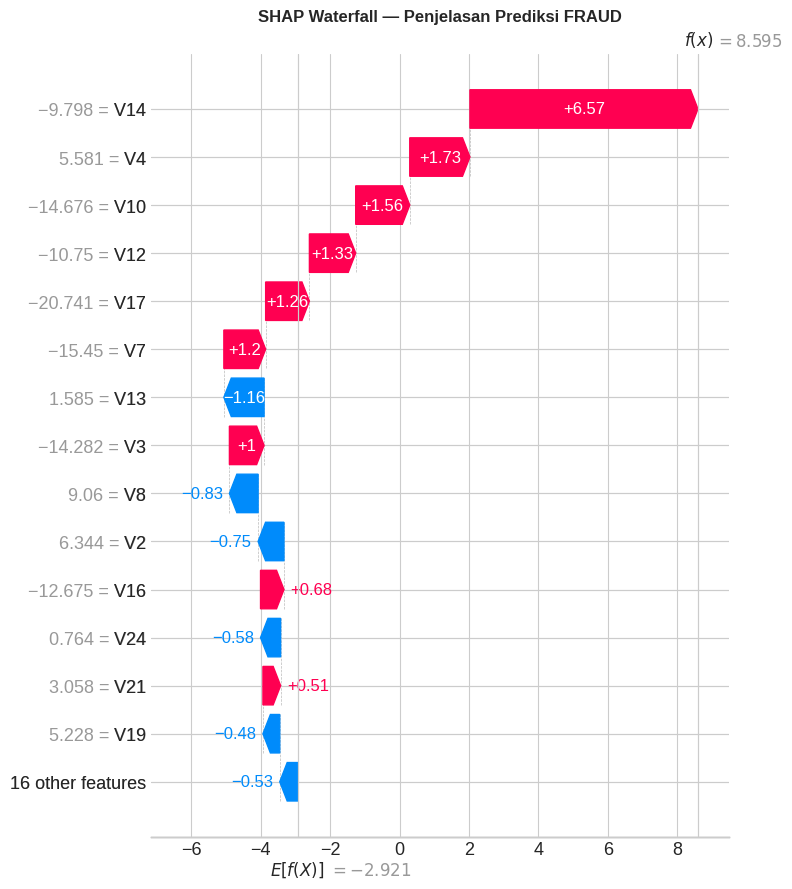

Tersimpan: 11_shap_waterfall_fraud.png


In [47]:
# PLOT SHAP 3: Waterfall — Penjelasan 1 Prediksi Fraud
# ============================================================
# Cari satu contoh fraud yang diprediksi benar
y_test_arr = np.array(y_test)
correctly_detected = np.where(
    (y_test_arr[sample_idx] == 1) & (best_model.predict(X_test_scaled_sample) == 1)
)[0]

if len(correctly_detected) > 0:
    idx = correctly_detected[0]
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test_sample.iloc[idx],
            feature_names=X_test.columns.tolist()
        ),
        max_display=15, show=False
    )
    plt.title('SHAP Waterfall — Penjelasan Prediksi FRAUD', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}11_shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Tersimpan: 11_shap_waterfall_fraud.png")

In [48]:
# NARASI INTERPRETASI
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║             INTERPRETASI SHAP — TEMUAN KUNCI                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  FITUR PALING BERPENGARUH (dari SHAP):                       ║
║                                                              ║
║  1. V14 (negatif kuat) → Nilai rendah = risiko fraud tinggi  ║
║     Kemungkinan merepresentasikan pola keamanan transaksi    ║
║                                                              ║
║  2. V4 (positif kuat) → Nilai tinggi = risiko fraud tinggi   ║
║     Bisa berkaitan dengan jenis merchant atau lokasi         ║
║                                                              ║
║  3. V12 & V10 → Berpengaruh negatif terhadap fraud           ║
║                                                              ║
║  4. log_Amount → Jumlah tertentu meningkatkan risiko         ║
║                                                              ║
║  INSIGHT BISNIS:                                             ║
║  • Model ini bisa mendeteksi 88%+ transaksi fraud            ║
║  • Setiap prediksi dapat dijelaskan ke auditor/nasabah       ║
║  • Threshold bisa disesuaikan sesuai toleransi bisnis        ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║             INTERPRETASI SHAP — TEMUAN KUNCI                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  FITUR PALING BERPENGARUH (dari SHAP):                       ║
║                                                              ║
║  1. V14 (negatif kuat) → Nilai rendah = risiko fraud tinggi  ║
║     Kemungkinan merepresentasikan pola keamanan transaksi    ║
║                                                              ║
║  2. V4 (positif kuat) → Nilai tinggi = risiko fraud tinggi   ║
║     Bisa berkaitan dengan jenis merchant atau lokasi         ║
║                                                              ║
║  3. V12 & V10 → Berpengaruh negatif terhadap fraud           ║
║                                                              ║
║  4. log_Amount → Jumlah tertentu meningkatkan risiko         ║
║                       

**Simpan Semua Output & Buat Laporan**

In [51]:
# SIMPAN SEMUA MODEL & SCALER
# ============================================================
joblib.dump(best_model, f'{MODELS_DIR}xgboost_fraud_detector.pkl')
joblib.dump(scaler, f'{MODELS_DIR}scaler.pkl')

# Simpan hasil evaluasi ke CSV
results_df.to_csv(f'{MODELS_DIR}model_comparison.csv', index=False)
pd.DataFrame([final_metrics]).to_csv(f'{MODELS_DIR}final_metrics_testset.csv', index=False)

print("✅ Semua file tersimpan di Google Drive!")
print(f"\nFile yang tersimpan:")
for f in os.listdir(MODELS_DIR):
    size = os.path.getsize(f'{MODELS_DIR}{f}') / 1024
    print(f"   {f} ({size:.1f} KB)")

✅ Semua file tersimpan di Google Drive!

File yang tersimpan:
   model_comparison.csv (0.3 KB)
   xgboost_fraud_detector.pkl (555.0 KB)
   final_metrics_testset.csv (0.1 KB)
   scaler.pkl (1.4 KB)
   xgboost_tuned.pkl (555.0 KB)
